SECTION 2 COMPLETE: Clean return series saved to 'assignment2_returns.csv'.

=== SUMMARY STATISTICS ===
             Mean   Std Dev  Skewness  Kurtosis       Min       Max
4GLD.DE  0.000692  0.008957 -0.275987  3.187779 -0.047661  0.047301
0DLT.L   0.000344  0.008515 -0.461335  4.063586 -0.058786  0.039846


--- MODEL COMPARISON TABLE (4GLD.DE) ---
         Model  LogLikelihood          AIC          BIC
    GARCH(1,1)    4164.446511 -8320.893023 -8300.382248
          EWMA    4140.405101 -8276.810201 -8266.554814
   RiskMetrics    4139.790870 -8279.581741 -8279.581741
GJR-GARCH(1,1)    4151.231228 -8292.462455 -8266.823987

--------------------------------------------------



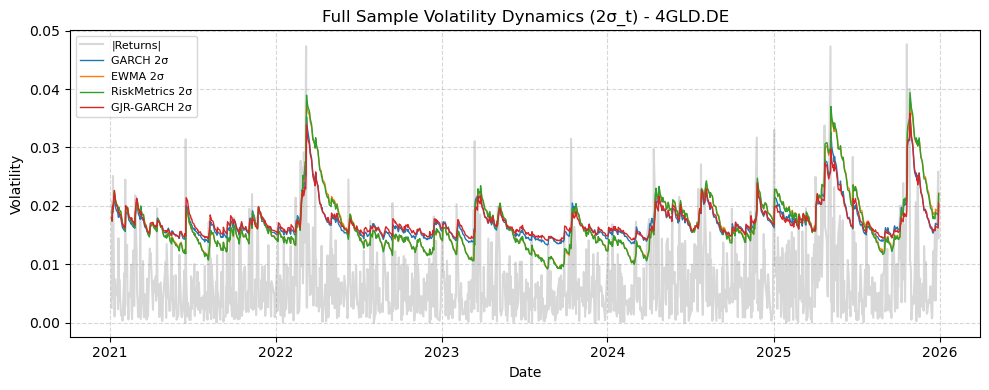

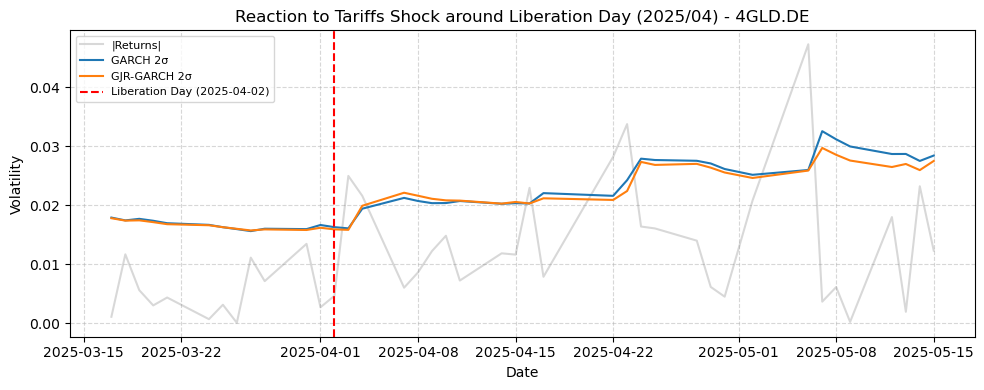

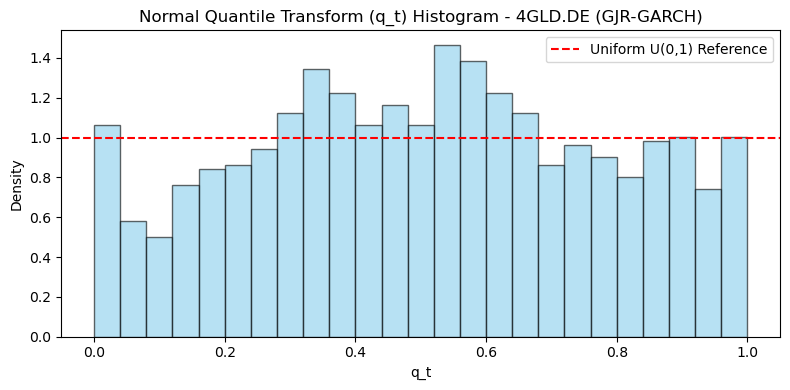

--- MODEL COMPARISON TABLE (0DLT.L) ---
         Model  LogLikelihood          AIC          BIC
    GARCH(1,1)    4218.320641 -8428.641281 -8408.130506
          EWMA    4200.151186 -8396.302373 -8386.046986
   RiskMetrics    4198.272401 -8396.544802 -8396.544802
GJR-GARCH(1,1)    4227.755868 -8445.511735 -8419.873267

--------------------------------------------------



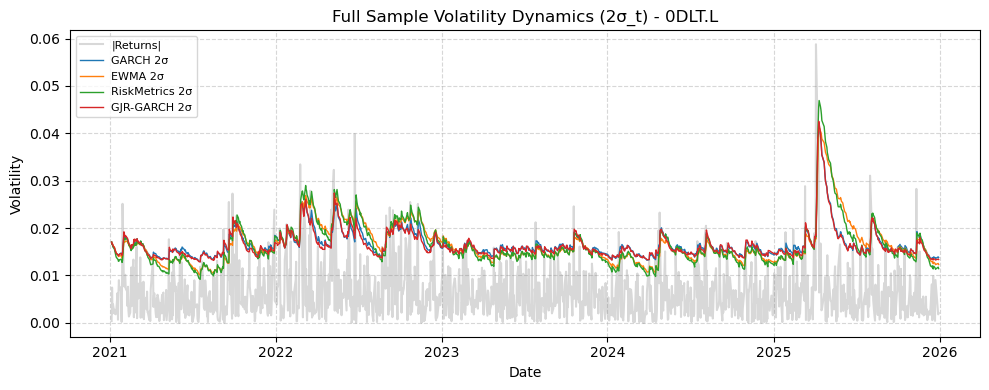

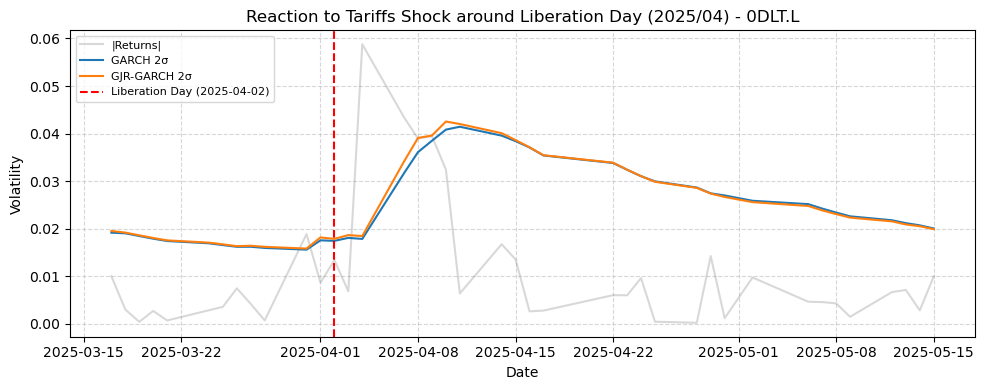

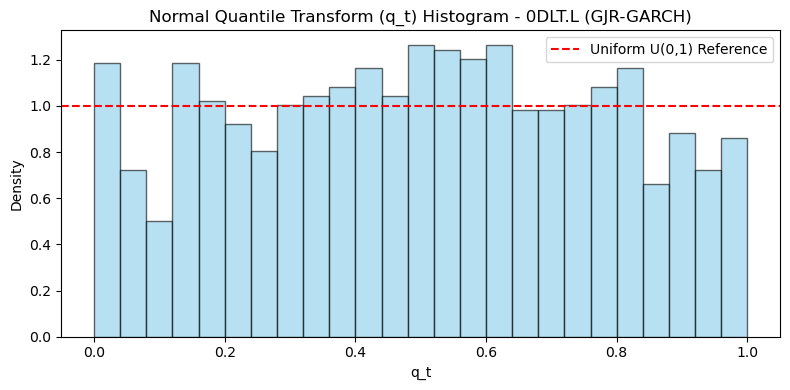

--- STANDARDIZED RESIDUAL CORRELATION BREAKDOWN ---
Full Sample Correlation:         0.0869
1st Third Sample (Initial):      0.0420
2nd Third Sample (Middle):       0.0544
3rd Third Sample (Late/Tariffs):  0.1542

--- DCC(1,1) PARAMETER ESTIMATES ---
Parameter a: 0.3000
Parameter b: 0.6857
Persistence (a + b): 0.9857



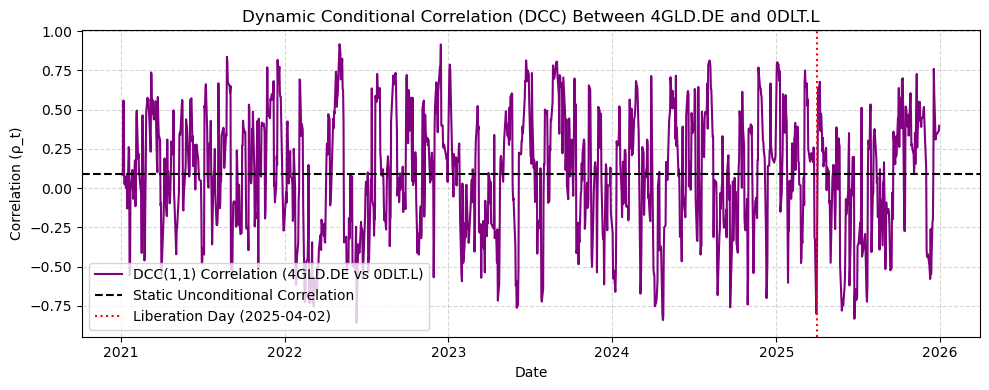

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# 1. DATA PREPARATION & CLEANING (SECTION 2)
# ==========================================
df_de = pd.read_csv("etf_full-DE.csv", parse_dates=["Date"]).set_index("Date").sort_index()
df_lse = pd.read_csv("etf_full-L.csv", parse_dates=["Date"]).set_index("Date").sort_index()

# Select chosen ETFs
prices = df_de[["4GLD.DE"]].join(df_lse[["0DLT.L"]], how="inner").dropna()

# Compute log-returns and save clean series
returns = np.log(prices / prices.shift(1)).dropna()
returns.to_csv("assignment2_returns.csv")
print("SECTION 2 COMPLETE: Clean return series saved to 'assignment2_returns.csv'.\n")

# Display Summary Statistics
print("=== SUMMARY STATISTICS ===")
summary_stats = pd.DataFrame({
    'Mean': returns.mean(),
    'Std Dev': returns.std(),
    'Skewness': returns.skew(),
    'Kurtosis': returns.kurtosis(),
    'Min': returns.min(),
    'Max': returns.max()
})
print(summary_stats.to_string())
print("\n" + "="*50 + "\n")


# ==========================================
# 2. MODEL ESTIMATION FUNCTIONS
# ==========================================

def fit_garch(y):
    T = len(y)
    def neg_loglik(params):
        mu, omega, alpha, beta = params
        u = y - mu
        sigma2 = np.zeros(T)
        sigma2[0] = np.var(u)
        for t in range(1, T):
            sigma2[t] = omega + alpha * (u[t-1]**2) + beta * sigma2[t-1]
            if sigma2[t] <= 1e-8:
                sigma2[t] = 1e-8
        return 0.5 * np.sum(np.log(2 * np.pi * sigma2) + (u**2) / sigma2)

    res = minimize(
        neg_loglik,
        [np.mean(y), 1e-5, 0.05, 0.90],
        bounds=[(-1, 1), (1e-8, None), (1e-8, 1.0), (1e-8, 1.0)],
        method="L-BFGS-B"
    )
    mu, omega, alpha, beta = res.x
    u = y - mu
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(u)
    for t in range(1, T):
        sigma2[t] = omega + alpha * (u[t-1]**2) + beta * sigma2[t-1]
        if sigma2[t] <= 1e-8:
            sigma2[t] = 1e-8
    
    loglik = -res.fun
    k = 4
    return {
        "params": [mu, omega, alpha, beta],
        "vol": np.sqrt(sigma2),
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "bic": k * np.log(T) - 2 * loglik,
        "u": u,
        "v": u / np.sqrt(sigma2)
    }

def fit_ewma(y):
    T = len(y)
    def neg_loglik(params):
        mu, delta = params
        u = y - mu
        sigma2 = np.zeros(T)
        sigma2[0] = np.var(u)
        alpha = 1 - delta
        for t in range(1, T):
            sigma2[t] = alpha * (u[t-1]**2) + delta * sigma2[t-1]
            if sigma2[t] <= 1e-8:
                sigma2[t] = 1e-8
        return 0.5 * np.sum(np.log(2 * np.pi * sigma2) + (u**2) / sigma2)

    res = minimize(
        neg_loglik,
        [np.mean(y), 0.94],
        bounds=[(-1, 1), (0.01, 0.99)],
        method="L-BFGS-B"
    )
    mu, delta = res.x
    u = y - mu
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(u)
    alpha = 1 - delta
    for t in range(1, T):
        sigma2[t] = alpha * (u[t-1]**2) + delta * sigma2[t-1]
        if sigma2[t] <= 1e-8:
            sigma2[t] = 1e-8

    loglik = -res.fun
    k = 2
    return {
        "params": [mu, 0.0, alpha, delta],
        "vol": np.sqrt(sigma2),
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "bic": k * np.log(T) - 2 * loglik,
        "u": u,
        "v": u / np.sqrt(sigma2)
    }

def fit_riskmetrics(y):
    T = len(y)
    mu = np.mean(y)
    delta = 0.94
    alpha = 0.06
    u = y - mu
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(u)
    for t in range(1, T):
        sigma2[t] = alpha * (u[t-1]**2) + delta * sigma2[t-1]
        if sigma2[t] <= 1e-8:
            sigma2[t] = 1e-8

    loglik = -0.5 * np.sum(np.log(2 * np.pi * sigma2) + (u**2) / sigma2)
    k = 0
    return {
        "params": [mu, 0.0, alpha, delta],
        "vol": np.sqrt(sigma2),
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "bic": k * np.log(T) - 2 * loglik,
        "u": u,
        "v": u / np.sqrt(sigma2)
    }

def fit_gjr_garch(y):
    T = len(y)
    def neg_loglik(params):
        mu, omega, alpha, gamma, beta = params
        u = y - mu
        sigma2 = np.zeros(T)
        sigma2[0] = np.var(u)
        for t in range(1, T):
            I = 1.0 if u[t-1] < 0 else 0.0
            sigma2[t] = omega + alpha * (u[t-1]**2) + gamma * (u[t-1]**2) * I + beta * sigma2[t-1]
            if sigma2[t] <= 1e-8:
                sigma2[t] = 1e-8
        return 0.5 * np.sum(np.log(2 * np.pi * sigma2) + (u**2) / sigma2)

    res = minimize(
        neg_loglik,
        [np.mean(y), 1e-5, 0.03, 0.03, 0.90],
        bounds=[(-1, 1), (1e-8, None), (1e-8, 1.0), (-1.0, 1.0), (1e-8, 1.0)],
        method="L-BFGS-B"
    )
    mu, omega, alpha, gamma, beta = res.x
    u = y - mu
    sigma2 = np.zeros(T)
    sigma2[0] = np.var(u)
    for t in range(1, T):
        I = 1.0 if u[t-1] < 0 else 0.0
        sigma2[t] = omega + alpha * (u[t-1]**2) + gamma * (u[t-1]**2) * I + beta * sigma2[t-1]
        if sigma2[t] <= 1e-8:
            sigma2[t] = 1e-8

    loglik = -res.fun
    k = 5
    return {
        "params": [mu, omega, alpha, gamma, beta],
        "vol": np.sqrt(sigma2),
        "loglik": loglik,
        "aic": 2 * k - 2 * loglik,
        "bic": k * np.log(T) - 2 * loglik,
        "u": u,
        "v": u / np.sqrt(sigma2)
    }


# ==========================================
# 3. SECTION 4: UNIVARIATE MODELING FOR BOTH ETFS
# ==========================================
fitted_models = {}

for asset in returns.columns:
    y = returns[asset].values
    g = fit_garch(y)
    e = fit_ewma(y)
    rm = fit_riskmetrics(y)
    gjr = fit_gjr_garch(y)
    
    fitted_models[asset] = {'GARCH': g, 'EWMA': e, 'RiskMetrics': rm, 'GJR-GARCH': gjr}
    
    # 3.1 Model Comparison Table
    print(f"--- MODEL COMPARISON TABLE ({asset}) ---")
    df_table = pd.DataFrame({
        'Model': ['GARCH(1,1)', 'EWMA', 'RiskMetrics', 'GJR-GARCH(1,1)'],
        'LogLikelihood': [g['loglik'], e['loglik'], rm['loglik'], gjr['loglik']],
        'AIC': [g['aic'], e['aic'], rm['aic'], gjr['aic']],
        'BIC': [g['bic'], e['bic'], rm['bic'], gjr['bic']]
    })
    print(df_table.to_string(index=False))
    print("\n" + "-"*50 + "\n")

    # 3.2 Full Sample Volatility Dynamics Plot (2*sigma_t)
    plt.figure(figsize=(10, 4))
    plt.plot(returns.index, np.abs(y), color='grey', alpha=0.3, label='|Returns|')
    plt.plot(returns.index, 2 * g['vol'], label='GARCH 2σ', linewidth=1)
    plt.plot(returns.index, 2 * e['vol'], label='EWMA 2σ', linewidth=1)
    plt.plot(returns.index, 2 * rm['vol'], label='RiskMetrics 2σ', linewidth=1)
    plt.plot(returns.index, 2 * gjr['vol'], label='GJR-GARCH 2σ', linewidth=1)
    plt.title(f'Full Sample Volatility Dynamics (2σ_t) - {asset}')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend(loc='upper left', fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 3.3 Reaction to Tariffs Shock around Liberation Day (2025/04)
    shock_mask = (returns.index >= '2025-03-15') & (returns.index <= '2025-05-15')
    shock_dates = returns.index[shock_mask]
    
    plt.figure(figsize=(10, 4))
    plt.plot(shock_dates, np.abs(y[shock_mask]), color='grey', alpha=0.3, label='|Returns|')
    plt.plot(shock_dates, 2 * g['vol'][shock_mask], label='GARCH 2σ', linewidth=1.5)
    plt.plot(shock_dates, 2 * gjr['vol'][shock_mask], label='GJR-GARCH 2σ', linewidth=1.5)
    plt.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle='--', label='Liberation Day (2025-04-02)')
    plt.title(f'Reaction to Tariffs Shock around Liberation Day (2025/04) - {asset}')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.legend(loc='upper left', fontsize=8)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # 3.4 Normal Quantile Transform (q_t) Histogram for GJR-GARCH
    v_t = gjr['v']
    q_t = norm.cdf(v_t)
    
    plt.figure(figsize=(8, 4))
    plt.hist(q_t, bins=25, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    plt.axhline(1.0, color='red', linestyle='--', label='Uniform U(0,1) Reference')
    plt.title(f'Normal Quantile Transform (q_t) Histogram - {asset} (GJR-GARCH)')
    plt.xlabel('q_t')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()


# ==========================================
# 4. SECTION 5: EXTRA - BIVARIATE CORRELATION & DCC
# ==========================================
print("--- STANDARDIZED RESIDUAL CORRELATION BREAKDOWN ---")
v1 = fitted_models[returns.columns[0]]['GJR-GARCH']['v']
v2 = fitted_models[returns.columns[1]]['GJR-GARCH']['v']

V = np.column_stack([v1, v2])
T = len(V)

# Static Sub-sample Correlations
full_corr = np.corrcoef(v1, v2)[0, 1]
third = T // 3

corr_1st = np.corrcoef(v1[:third], v2[:third])[0, 1]
corr_2nd = np.corrcoef(v1[third:2*third], v2[third:2*third])[0, 1]
corr_3rd = np.corrcoef(v1[2*third:], v2[2*third:])[0, 1]

print(f"Full Sample Correlation:         {full_corr:.4f}")
print(f"1st Third Sample (Initial):      {corr_1st:.4f}")
print(f"2nd Third Sample (Middle):       {corr_2nd:.4f}")
print(f"3rd Third Sample (Late/Tariffs):  {corr_3rd:.4f}\n")

# DCC Optimization
S = np.cov(V, rowvar=False)

def dcc_neg_loglik(params):
    a, b = params
    if a <= 0 or b <= 0 or (a + b) >= 0.999:
        return 1e10
    
    Q = S.copy()
    loglik = 0.0
    for t in range(T):
        vt = V[t:t+1, :]
        Q = S * (1 - a - b) + a * (vt.T @ vt) + b * Q
        q_diag = np.sqrt(np.diag(Q))
        R = Q / np.outer(q_diag, q_diag)
        
        det_R = np.linalg.det(R)
        inv_R = np.linalg.inv(R)
        loglik += 0.5 * (np.log(det_R) + vt @ inv_R @ vt.T - vt @ vt.T)
        
    return float(np.squeeze(loglik))

dcc_res = minimize(
    dcc_neg_loglik,
    [0.05, 0.85],
    bounds=[(1e-4, 0.3), (1e-4, 0.98)],
    method="L-BFGS-B"
)

a_opt, b_opt = dcc_res.x
print("--- DCC(1,1) PARAMETER ESTIMATES ---")
print(f"Parameter a: {a_opt:.4f}")
print(f"Parameter b: {b_opt:.4f}")
print(f"Persistence (a + b): {a_opt + b_opt:.4f}\n")

# Plot Dynamic Correlation over time
Q = S.copy()
rho_12 = np.zeros(T)
for t in range(T):
    vt = V[t:t+1, :]
    Q = S * (1 - a_opt - b_opt) + a_opt * (vt.T @ vt) + b_opt * Q
    q_diag = np.sqrt(np.diag(Q))
    R = Q / np.outer(q_diag, q_diag)
    rho_12[t] = R[0, 1]

plt.figure(figsize=(10, 4))
plt.plot(returns.index, rho_12, color='purple', label=f'DCC(1,1) Correlation ({returns.columns[0]} vs {returns.columns[1]})')
plt.axhline(full_corr, color='black', linestyle='--', label='Static Unconditional Correlation')
plt.axvline(pd.Timestamp('2025-04-02'), color='red', linestyle=':', label='Liberation Day (2025-04-02)')
plt.title(f'Dynamic Conditional Correlation (DCC) Between {returns.columns[0]} and {returns.columns[1]}')
plt.xlabel('Date')
plt.ylabel('Correlation (ρ_t)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()